In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_ligbuilder = pd.read_csv('../Datasets/concat_datasets_both_with_ID.csv')
df_vina = pd.read_csv('../Datasets/vina_best_per_molecule_sorted_VS.csv')
df_vina.rename(columns={'Ligand_name': 'ID'}, inplace=True)

In [3]:
df_vina

,rank,molecule_name,score,smiles,library,ID,tautomer_id
0,1,Druglike_1497-1_out,-11.495,CCc1cc(=O)c2ccc(Nc3cccc4ncoc34)cc2[nH]1,Druglike,Druglike_1497,1
1,2,Druglike_33-1_out,-11.440,CCC#CCNCc1cc(-c2ccc(C(=O)c3noc(=O)[nH]3)[nH]2)...,Druglike,Druglike_33,1
2,3,Druglike_176-1_out,-11.297,Nc1cnc(C2=COCC=C2)cc1C#Cc1cc(F)ccc1C(=O)[O-],Druglike,Druglike_176,1
3,4,Druglike_1153-1_out,-11.111,O=C(c1cc([O-])[nH]n1)c1ncc(/C=C/c2cccc(Cl)c2)cn1,Druglike,Druglike_1153,1
4,5,Druglike_245-1_out,-10.995,Oc1ccc(F)cc1C#Cc1cncc(C2=CCC=CN2)c1,Druglike,Druglike_245,1
...,...,...,...,...,...,...,...
4393,4394,HighDiv_2307-1_out,-5.839,[NH3+]CCC(=O)NOc1c(I)ncc(O)c1[S-],HighDiv,HighDiv_2307,1
4394,4395,HighDiv_768-1_out,-5.784,O=C([O-])c1nc([C@H](O)CS)co1,HighDiv,HighDiv_768,1
4395,4396,HighDiv_1783-1_out,-5.762,CCO[P@](=O)([O-])c1ccc(S[S-])c(O)c1I,HighDiv,HighDiv_1783,1
4396,4397,Druglike_892-1_out,-5.568,O=C([O-])[C@@H]1CN/C(=C\CO)N1CBr,Druglike,Druglike_892,1


In [4]:
df_concatenated = pd.merge(df_ligbuilder, df_vina, on='ID', how='inner')
df_concatenated = df_concatenated.drop(columns=['smiles', 'rank'])
df_concatenated.head()

,SMILES,Name,InChI,Formula,MW,LogP,pKd,Structure,Synthesize,Chemical,SA_Score,SA_Score_Binary,Dataset,ID,molecule_name,score,library,tautomer_id
0,NC1=C2C=NNC2=NC([C@@H](/C=C/CC2=NC(CCCl)=CC=C2...,21/000000020,InChI=1S/C17H17ClN6O2/c18-8-7-11-4-1-3-10(21-1...,C17H17N6O2Cl,372.0,2.17,6.45,6.97,24.10,-190.0,3.895024,1,DRUGLIKE_CONCAT,Druglike_1,Druglike_1-1_out,-9.496,Druglike,1
1,NC1=C2C=NNC2=NC([C@@H](/C=C/CC2=NC=CC=C2CCBr)C...,21/000000030,InChI=1S/C17H17BrN6O2/c18-7-6-10-3-2-8-20-13(1...,C17H17N6O2Br,417.0,2.42,6.04,5.01,24.10,-190.0,3.978020,1,DRUGLIKE_CONCAT,Druglike_2,Druglike_2-1_out,-9.526,Druglike,1
2,NCOCC1=CC([C@@H](N)C2=NC(I)=C(C#CC(=O)O)C=C2)=CO1,26/000000135,InChI=1S/C15H14IN3O4/c16-15-9(2-4-13(20)21)1-3...,C15H14N3O4I,427.0,0.67,5.42,2.91,24.50,-190.0,4.196952,1,DRUGLIKE_CONCAT,Druglike_3,Druglike_3-2_out,-7.910,Druglike,2
3,CC(=O)C1=C[C@@H](C(=O)O)NC(/C=C/CNCC2=C(Br)C=N...,18/000000048,InChI=1S/C14H16BrN5O3/c1-8(21)10-5-11(14(22)23...,C14H16N5O3Br,382.0,0.49,5.39,6.63,5.23,-170.0,4.325905,1,DRUGLIKE_CONCAT,Druglike_4,Druglike_4-2_out,-9.558,Druglike,2
4,O=C(O)C1=CN=C(O)N=C1C/C=C/C1=NC(Br)=C(Cl)C=C1,29/000000167,InChI=1S/C13H9BrClN3O3/c14-11-9(15)5-4-7(17-11...,C13H9N3O3ClBr,370.0,2.46,5.37,7.30,5.21,0.0,3.366448,1,DRUGLIKE_CONCAT,Druglike_5,Druglike_5-1_out,-9.484,Druglike,1


In [5]:
def zscore(series):
    return (series - series.mean()) / series.std()

# Vina (score): inverte sinal — mais negativo é melhor, então -Z coloca os melhores no topo
df_concatenated['z_vina'] = -zscore(df_concatenated['score'])

# LigBuilder (pKd): mantém — maior pKd é melhor
df_concatenated['z_pkd'] = zscore(df_concatenated['pKd'])

# Consensus Z-score: média dos dois Z-scores normalizados
df_concatenated['consensus_z'] = df_concatenated[['z_vina', 'z_pkd']].mean(axis=1)

df_ranked = df_concatenated.sort_values('consensus_z', ascending=False).reset_index(drop=True)
df_ranked[['ID', 'score', 'pKd', 'z_vina', 'z_pkd', 'consensus_z']]

,ID,score,pKd,z_vina,z_pkd,consensus_z
0,Druglike_1,-9.496,6.45,1.343421,6.042542,3.692981
1,HighDiv_4,-10.609,5.86,2.570990,4.310268,3.440629
2,HighDiv_1581,-10.932,5.68,2.927239,3.781778,3.354509
3,HighDiv_1,-9.375,6.10,1.209965,5.014922,3.112444
4,Druglike_2,-9.526,6.04,1.376509,4.838759,3.107634
...,...,...,...,...,...,...
4393,HighDiv_2304,-5.931,4.04,-2.588551,-1.033354,-1.810953
4394,HighDiv_1898,-5.907,4.04,-2.615022,-1.033354,-1.824188
4395,HighDiv_1915,-5.886,4.02,-2.638184,-1.092075,-1.865129
4396,HighDiv_2307,-5.839,4.03,-2.690022,-1.062715,-1.876368


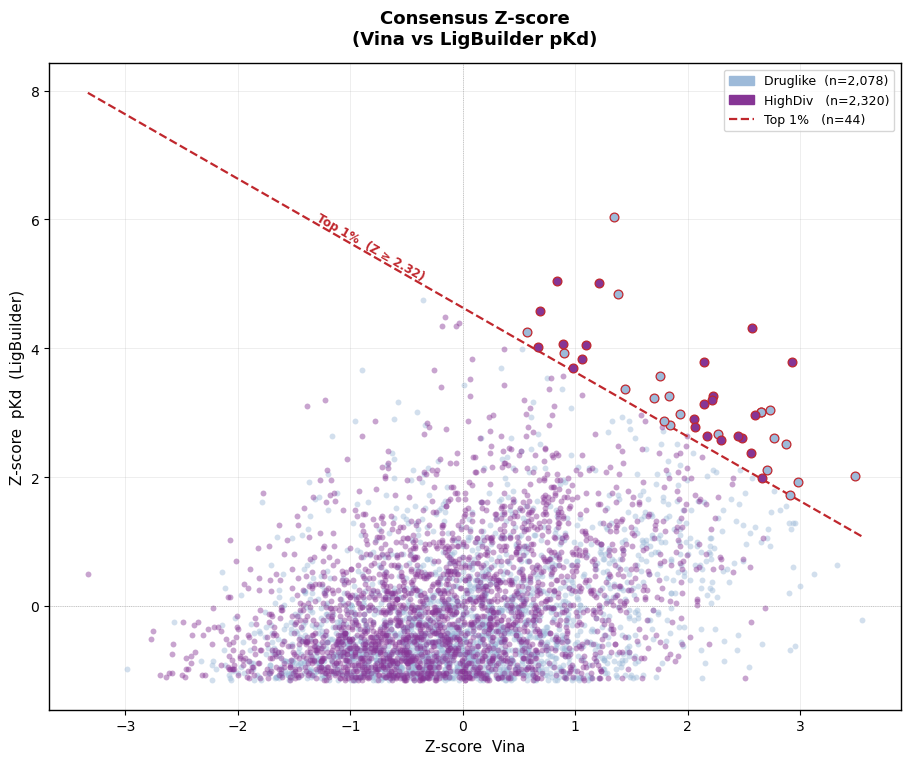

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# ── Cores BuPu ────────────────────────────────────────────────────────────────
cmap       = plt.cm.BuPu
COLOR_DRUG = cmap(0.38)
COLOR_HIGH = cmap(0.78)
TOP_EDGE   = "#C0272D"

# ── Subsets ───────────────────────────────────────────────────────────────────
threshold = df_ranked['consensus_z'].quantile(0.99)
top1      = df_ranked[df_ranked['consensus_z'] >= threshold]

drug     = df_ranked[df_ranked['library'] == 'Druglike']
high     = df_ranked[df_ranked['library'] == 'HighDiv']
top_drug = top1[top1['library'] == 'Druglike']
top_high = top1[top1['library'] == 'HighDiv']

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

# Pontos base
ax.scatter(drug['z_vina'], drug['z_pkd'],
           color=COLOR_DRUG, s=18, alpha=0.45, linewidths=0, rasterized=True)
ax.scatter(high['z_vina'], high['z_pkd'],
           color=COLOR_HIGH, s=18, alpha=0.45, linewidths=0, rasterized=True)

# Top 1% destacado
ax.scatter(top_drug['z_vina'], top_drug['z_pkd'],
           color=COLOR_DRUG, s=40, alpha=1.0,
           edgecolors=TOP_EDGE, linewidths=0.9, zorder=5)
ax.scatter(top_high['z_vina'], top_high['z_pkd'],
           color=COLOR_HIGH, s=40, alpha=1.0,
           edgecolors=TOP_EDGE, linewidths=0.9, zorder=5)

# Linhas de referência Z = 0
ax.axhline(0, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# Linha diagonal de cutoff
x_diag = np.linspace(df_ranked['z_vina'].min(), df_ranked['z_vina'].max(), 300)
y_diag = 2 * threshold - x_diag
ax.plot(x_diag, y_diag, color=TOP_EDGE, linewidth=1.6, linestyle='--', alpha=1.0, zorder=3)

# Ângulo real em coordenadas de display
plt.tight_layout()
fig.canvas.draw()
p1 = ax.transData.transform([x_diag[0],  y_diag[0]])
p2 = ax.transData.transform([x_diag[-1], y_diag[-1]])
angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

# Label: ancoragem deslocada perpendicularmente acima da linha
mid = len(x_diag) // 2
perp = 1
ax.text(x_diag[mid] - perp, y_diag[mid] + perp,
        f'  Top 1%  (Z ≥ {threshold:.2f})',
        color=TOP_EDGE, fontsize=8.5, ha='center', va='bottom', fontweight='bold',
        rotation=angle, rotation_mode='anchor', zorder=4)

# ── Estética ──────────────────────────────────────────────────────────────────
ax.set_xlabel('Z-score  Vina', fontsize=11)
ax.set_ylabel('Z-score  pKd  (LigBuilder)', fontsize=11)
ax.set_title('Consensus Z-score\n(Vina vs LigBuilder pKd)', fontsize=13, pad=14, fontweight='bold')

# Caixa completa (todos os spines visíveis)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')

# Grid sutil atrás dos pontos
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

# ── Legenda ───────────────────────────────────────────────────────────────────
patch_drug = mpatches.Patch(color=COLOR_DRUG, label=f'Druglike  (n={len(drug):,})')
patch_high = mpatches.Patch(color=COLOR_HIGH, label=f'HighDiv   (n={len(high):,})')
line_top   = mlines.Line2D([], [], color=TOP_EDGE, linewidth=1.6, linestyle='--',
                            label=f'Top 1%   (n={len(top1):,})')

ax.legend(handles=[patch_drug, patch_high, line_top],
          frameon=True, fontsize=9, loc='upper right')

plt.savefig('consensus_zscore_scatter.png', dpi=600, bbox_inches='tight')
plt.show()

In [16]:
cols = [
    'ID', 'library', 'SMILES', 'Name', 'Formula', 'MW', 'LogP',
    'pKd', 'score', 'z_pkd', 'z_vina', 'consensus_z',
    'SA_Score', 'Structure', 'Synthesize', 'Chemical', 'Dataset'
]

top1_export = top1[cols].sort_values('consensus_z', ascending=False).reset_index(drop=True)
top1_export.to_csv('top1pct_consensus_zscore.csv', index=False)

print(f"Salvos {len(top1_export)} compostos → top1pct_consensus_zscore.csv")
top1_export.head()

Salvos 44 compostos → top1pct_consensus_zscore.csv


,ID,library,SMILES,Name,Formula,MW,LogP,pKd,score,z_pkd,z_vina,consensus_z,SA_Score,Structure,Synthesize,Chemical,Dataset
0,Druglike_1,Druglike,NC1=C2C=NNC2=NC([C@@H](/C=C/CC2=NC(CCCl)=CC=C2...,21/000000020,C17H17N6O2Cl,372.0,2.17,6.45,-9.496,6.042542,1.343421,3.692981,3.895024,6.97,24.1,-190.0,DRUGLIKE_CONCAT
1,HighDiv_4,HighDiv,NOC1=CC(C(=O)O)=CC(OC/C=C/[C@@H]2NNC3=C2C=CC=C...,12/000001403,C17H16N3O4Br,406.0,2.98,5.86,-10.609,4.310268,2.570990,3.440629,3.709026,7.55,21.3,-190.0,HIGHDIVERSITY_CONCAT
2,HighDiv_1581,HighDiv,C=CC1=C(C(N)=O)SC2=CC=C([S@+]([O-])C3=CC(O)=C(...,12/000000150,C17H12NO4S2I,485.0,2.13,5.68,-10.932,3.781778,2.927239,3.354509,3.880718,6.18,24.8,-40.0,HIGHDIVERSITY_LANAPDB
3,HighDiv_1,HighDiv,C[C@H](CN)CC#CC1=CC(C(=O)CO)=CC(N=O)=C1Br,12/000000691,C14H16N2O3Br,340.0,1.76,6.10,-9.375,5.014922,1.209965,3.112444,4.386506,5.24,20.7,-170.0,HIGHDIVERSITY_CONCAT
4,Druglike_2,Druglike,NC1=C2C=NNC2=NC([C@@H](/C=C/CC2=NC=CC=C2CCBr)C...,21/000000030,C17H17N6O2Br,417.0,2.42,6.04,-9.526,4.838759,1.376509,3.107634,3.978020,5.01,24.1,-190.0,DRUGLIKE_CONCAT


In [17]:
df_ranked[cols].to_csv('all_consensus_zscore.csv', index=False)
print(f"Salvos {len(df_ranked)} compostos → all_consensus_zscore.csv")

Salvos 4398 compostos → all_consensus_zscore.csv
